#1. Process Audio Files Individually

In [ ]:
import librosa
import numpy as np
import os
import glob
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
# IMPORTANT: Update these paths to match the exact folder names in your Google Drive!
INPUT_FOLDER = "/content/drive/MyDrive/Podcast_Audio_Files"
OUTPUT_FOLDER = "/content/drive/MyDrive/Podcast_Codewords"

WINDOW_LENGTH_MS = 85.3

# The 22 Bark-band frequency edges defined in the research paper
bark_edges = [0, 100, 200, 300, 400, 510, 630, 770, 920, 1080, 1270,
              1480, 1720, 2000, 2320, 2700, 3150, 3700, 4400, 5300,
              6400, 7700, 9500]

# ==========================================
# 2. BATCH PROCESSING LOGIC
# ==========================================
def process_audio_folder():
    # Create the output folder if it doesn't exist yet
    if not os.path.exists(OUTPUT_FOLDER):
        os.makedirs(OUTPUT_FOLDER)

    # Find all mp3 and wav files in the input folder
    search_pattern_mp3 = os.path.join(INPUT_FOLDER, "*.mp3")
    search_pattern_wav = os.path.join(INPUT_FOLDER, "*.wav")
    audio_files = glob.glob(search_pattern_mp3) + glob.glob(search_pattern_wav)

    if len(audio_files) == 0:
        print(f"Error: No audio files found in {INPUT_FOLDER}")
        return

    print(f"Found {len(audio_files)} audio files. Starting batch analysis...\n")

    for current_file_num, audio_path in enumerate(audio_files, 1):
        # Extract the base name (e.g., "Episode_1" from "Episode_1.mp3")
        base_name = os.path.splitext(os.path.basename(audio_path))[0]

        # Create the output filename
        output_filename = os.path.join(OUTPUT_FOLDER, f"{base_name}_{WINDOW_LENGTH_MS}ms_codewords.txt")

        # Skip this file if the text file was already generated in a previous run
        if os.path.exists(output_filename):
            print(f"[{current_file_num}/{len(audio_files)}] '{base_name}' already processed. Skipping...")
            continue

        print(f"[{current_file_num}/{len(audio_files)}] Analyzing: {base_name}...")

        try:
            # --- Load Audio ---
            y, sr = librosa.load(audio_path, sr=None)

            # --- Framing & Power Spectrum ---
            win_length = int(sr * (WINDOW_LENGTH_MS / 1000.0))
            hop_length = win_length

            stft_matrix = librosa.stft(y, n_fft=win_length, hop_length=hop_length, window='blackmanharris')
            power_spectrum = np.abs(stft_matrix)**2
            fft_freqs = librosa.fft_frequencies(sr=sr, n_fft=win_length)

            # --- Bark-Band Grouping ---
            num_windows = power_spectrum.shape[1]
            bark_spectrogram = np.zeros((22, num_windows))

            for i in range(22):
                lower_bound = bark_edges[i]
                upper_bound = bark_edges[i+1]
                idx = np.where((fft_freqs >= lower_bound) & (fft_freqs < upper_bound))[0]
                bark_spectrogram[i, :] = np.sum(power_spectrum[idx, :], axis=0)

            window_energy_sums = np.sum(bark_spectrogram, axis=0) + 1e-10
            norm_bark = bark_spectrogram / window_energy_sums

            # --- Quantization ---
            medians = np.median(norm_bark, axis=1, keepdims=True)
            quantized_bark = (norm_bark >= medians).astype(int)

            code_words = []
            for j in range(num_windows):
                word = "".join(quantized_bark[:, j].astype(str))
                code_words.append(word)

            # --- Data Export ---
            with open(output_filename, 'w') as f:
                for word in code_words:
                    f.write(word + "\n")

            print(f"  -> ✅ Exported {num_windows} code-words to Drive.")

        except Exception as e:
            print(f"  -> ❌ Error processing {base_name}. Skipping. Details: {e}")

    print("\n🎉 Batch analysis complete! All code-words exported to your Drive.")

# ==========================================
# 3. RUN THE SCRIPT
# ==========================================
process_audio_folder()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 75 audio files. Starting batch analysis...

[1/75] Analyzing: 450...
  -> ✅ Exported 34767 code-words to Drive.
[2/75] Analyzing: 472...
  -> ✅ Exported 111303 code-words to Drive.
[3/75] Analyzing: 484...
  -> ✅ Exported 99542 code-words to Drive.
[4/75] Analyzing: 463...
  -> ✅ Exported 91604 code-words to Drive.
[5/75] Analyzing: 469...
  -> ✅ Exported 80680 code-words to Drive.
[6/75] Analyzing: 455...
  -> ✅ Exported 113873 code-words to Drive.
[7/75] Analyzing: 483...
  -> ✅ Exported 103301 code-words to Drive.
[8/75] Analyzing: 475...
  -> ✅ Exported 100036 code-words to Drive.
[9/75] Analyzing: 466...
  -> ✅ Exported 106391 code-words to Drive.
[10/75] Analyzing: 488...
  -> ✅ Exported 123669 code-words to Drive.
[11/75] Analyzing: 486...
  -> ✅ Exported 110393 code-words to Drive.
[12/75] Analyzing: 442...
  -> ✅ Exported 31449 code-words to Dr

#2. Find Total Audio Runtime

In [ ]:
import os
import glob
import librosa
import datetime
from google.colab import drive

# Connect to Drive (if not already connected in this session)
drive.mount('/content/drive')

# IMPORTANT: Update this if your folder name is different
AUDIO_FOLDER = "/content/drive/MyDrive/Podcast_Audio_Files"

print("Scanning audio files to calculate total duration...")
search_pattern_mp3 = os.path.join(AUDIO_FOLDER, "*.mp3")
search_pattern_wav = os.path.join(AUDIO_FOLDER, "*.wav")
audio_files = glob.glob(search_pattern_mp3) + glob.glob(search_pattern_wav)

total_seconds = 0

if not audio_files:
    print(f"Error: No audio files found in {AUDIO_FOLDER}")
else:
    for current_num, file in enumerate(audio_files, 1):
        try:
            # We use 'path=' so librosa only reads the metadata (which is instant)
            # instead of loading the massive audio file into RAM
            duration = librosa.get_duration(path=file)
            total_seconds += duration
        except Exception as e:
            print(f"Could not read {file}: {e}")

    # Convert raw seconds into a readable HH:MM:SS format
    formatted_time = str(datetime.timedelta(seconds=int(total_seconds)))

    print(f"\n======================================")
    print(f"🎯 DATASET DURATION REPORT")
    print(f"======================================")
    print(f"Total audio files found: {len(audio_files)}")
    print(f"Total duration (HH:MM:SS): {formatted_time}")
    print(f"Total decimal hours: {total_seconds / 3600:.2f} hours")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scanning audio files to calculate total duration...

🎯 DATASET DURATION REPORT
Total audio files found: 75
Total duration (HH:MM:SS): 7 days, 6:03:02
Total decimal hours: 174.05 hours


#3. The Master Zipf's Law Graph

Finding all codeword text files...
Found 75 data files. Aggregating all codewords...

[1/75] Added 34,767 frames from 450_85.3ms_codewords.txt...
[2/75] Added 111,303 frames from 472_85.3ms_codewords.txt...
[3/75] Added 99,542 frames from 484_85.3ms_codewords.txt...
[4/75] Added 91,604 frames from 463_85.3ms_codewords.txt...
[5/75] Added 80,680 frames from 469_85.3ms_codewords.txt...
[6/75] Added 113,873 frames from 455_85.3ms_codewords.txt...
[7/75] Added 103,301 frames from 483_85.3ms_codewords.txt...
[8/75] Added 100,036 frames from 475_85.3ms_codewords.txt...
[9/75] Added 106,391 frames from 466_85.3ms_codewords.txt...
[10/75] Added 123,669 frames from 488_85.3ms_codewords.txt...
[11/75] Added 110,393 frames from 486_85.3ms_codewords.txt...
[12/75] Added 31,449 frames from 442_85.3ms_codewords.txt...
[13/75] Added 79,689 frames from 422_85.3ms_codewords.txt...
[14/75] Added 132,422 frames from 454_85.3ms_codewords.txt...
[15/75] Added 112,292 frames from 485_85.3ms_codewords.txt...

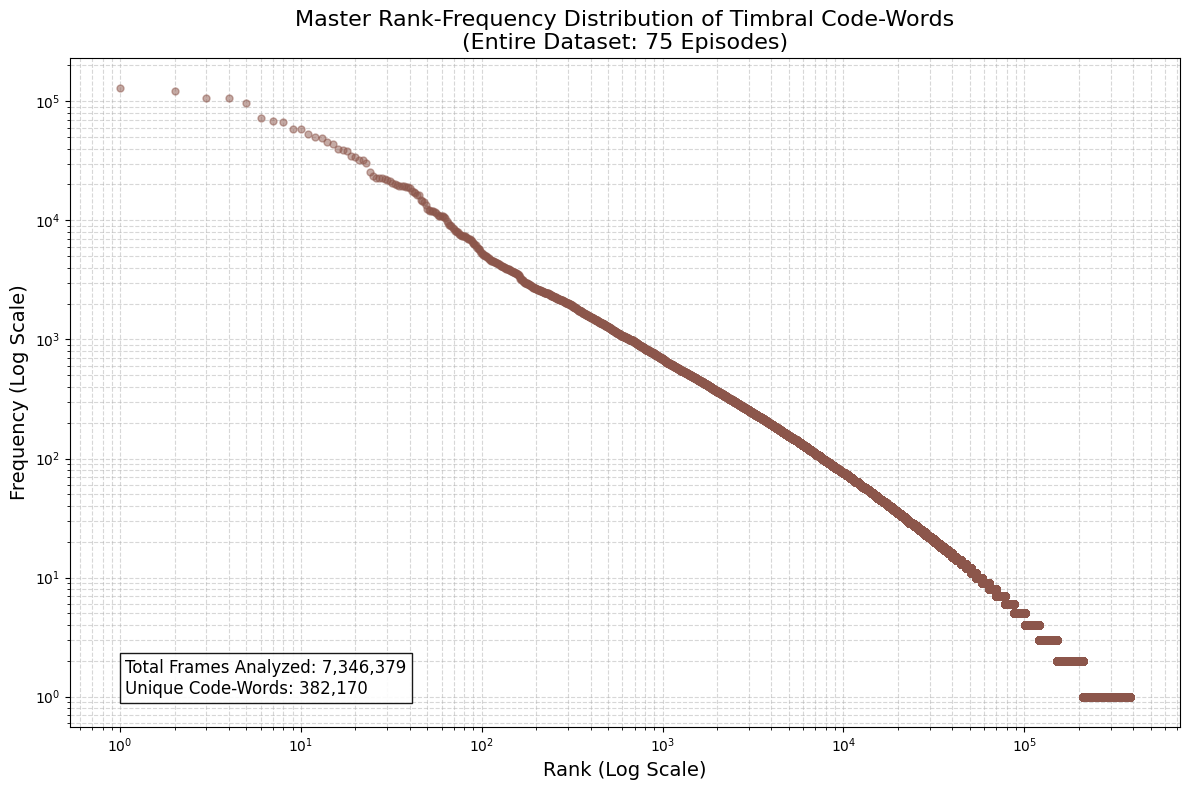


✅ MASTER AGGREGATION COMPLETE!
Total files processed: 75
Total individual frames analyzed: 7,346,379
Number of unique code-words found: 382,170
High-res graph saved to: /content/drive/MyDrive/Podcast_Codewords/MASTER_Zipfs_Law_Graph.png


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# IMPORTANT: Update this if your folder name is different
CODEWORDS_FOLDER = "/content/drive/MyDrive/Podcast_Codewords"

print("Finding all codeword text files...")
txt_files = glob.glob(os.path.join(CODEWORDS_FOLDER, "*.txt"))

if not txt_files:
    print(f"Error: No text files found in {CODEWORDS_FOLDER}")
else:
    print(f"Found {len(txt_files)} data files. Aggregating all codewords...\n")

    # A Counter is highly efficient for tallying massive amounts of data
    global_counts = Counter()
    total_frames = 0

    for current_num, file in enumerate(txt_files, 1):
        try:
            with open(file, 'r') as f:
                # Read the lines and instantly add them to the master tally
                lines = f.read().splitlines()
                global_counts.update(lines)
                total_frames += len(lines)
                print(f"[{current_num}/{len(txt_files)}] Added {len(lines):,} frames from {os.path.basename(file)}...")
        except Exception as e:
            print(f"Error reading {file}: {e}")

    # Sorting for Zipf's Law
    print("\nSorting global frequencies and preparing the master graph...")
    frequencies = sorted(list(global_counts.values()), reverse=True)
    ranks = np.arange(1, len(frequencies) + 1)

    unique_words = len(ranks)

    # Plotting the Master Graph
    plt.figure(figsize=(12, 8))
    plt.loglog(ranks, frequencies, marker='o', linestyle='none', color='#8c564b', alpha=0.5, markersize=5)
    plt.xlabel("Rank (Log Scale)", fontsize=14)
    plt.ylabel("Frequency (Log Scale)", fontsize=14)
    plt.title(f"Master Rank-Frequency Distribution of Timbral Code-Words\n(Entire Dataset: {len(txt_files)} Episodes)", fontsize=16)
    plt.grid(True, which="both", ls="--", alpha=0.5)

    # Add a professional text box with your final stats directly onto the chart
    stats_text = f"Total Frames Analyzed: {total_frames:,}\nUnique Code-Words: {unique_words:,}"
    plt.text(0.05, 0.05, stats_text, transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

    plt.tight_layout()

    # Save the graph directly to your drive as a high-res image!
    output_image = os.path.join(CODEWORDS_FOLDER, "MASTER_Zipfs_Law_Graph.png")
    plt.savefig(output_image, dpi=300)
    plt.show()

    print(f"\n✅ MASTER AGGREGATION COMPLETE!")
    print(f"Total files processed: {len(txt_files)}")
    print(f"Total individual frames analyzed: {total_frames:,}")
    print(f"Number of unique code-words found: {unique_words:,}")
    print(f"High-res graph saved to: {output_image}")